In [32]:
"""Video-level time-series inference using YOLO segmentation.

Extracts fish counts and total mask surface area (in pixels) over time for
entire video recordings.
"""

from dataclasses import dataclass
from dataclasses import dataclass, field

import logging
import os
from pathlib import Path
import re
from typing import Dict, List, Optional, Tuple
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from ultralytics import YOLO

# ==============================================================================
# 1. LOGGING & WARNINGS SETUP
# ==============================================================================
warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("VideoTimeSeriesAnalysis")


# ==============================================================================
# 2. CENTRAL CONFIGURATION
# ==============================================================================
@dataclass(frozen=True)
class VideoInferenceConfig:
    """Configuration for full video inference and time-series extraction."""

    # Paths
    recordings_dir: Path = Path("./recordings_counted/cropped_frames")
    model_path: Path = Path("./runs/segment/train-19/weights/best.pt")
    output_dir: Path = Path("./video_timeseries_output")
    tracker_config: Path = Path("./yolo26_config_1.yaml")

    # Inference hyperparameters
    conf_threshold: float = 0.50
    retina_masks: bool = True  # Ensures high-resolution pixel-accurate masks
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Ground truth fish counts per video
    gt_counts: Dict[str, int] = field(
        default_factory=lambda: {
            "fishvideo30": 41,
            "fishvideo31": 15,
            "fishvideo32": 15,
            "fishvideo33": 35,
            "fishvideo34": 35,
            "fishvideo38": 44,
            "fishvideo39": 30,
            "fishvideo40": 30,
            "fishvideo80": 15,
            "fishvideo81": 15,
            "fishvideo82": 15,
            "fishvideo83": 15,
            "fishvideo84": 35,
            "fishvideo85": 35,
            "fishvideo86": 30,
        }
    )



CONFIG = VideoInferenceConfig()
#CONFIG.output_dir.mkdir(parents=True, exist_ok=True)

logger.info(f"Execution device: {CONFIG.device}")
logger.info(f"Recordings directory: {CONFIG.recordings_dir.resolve()}")
logger.info(f"YOLO Model path: {CONFIG.model_path.resolve()}")
logger.info("Setup and imports initialized successfully.")

[16:17:19] [INFO] Execution device: cuda
[16:17:19] [INFO] Recordings directory: /mnt/c/Users/sinke/Desktop/Masterarbeit/yolo/recordings_counted/cropped_frames
[16:17:19] [INFO] YOLO Model path: /mnt/c/Users/sinke/Desktop/Masterarbeit/yolo/runs/segment/train-19/weights/best.pt
[16:17:19] [INFO] Setup and imports initialized successfully.


## YOLO prediction on each image (no tracking)

In [18]:
# ==============================================================================
# FULL VIDEO INFERENCE & TIME-SERIES EXTRACTION
# ==============================================================================

# 1. Load YOLO model
logger.info(f"Loading YOLO model from: {CONFIG.model_path}")
model = YOLO(str(CONFIG.model_path))

# 2. Strictly filter directories matching pattern: 'frames_fishvideo{number}'
pattern = re.compile(r"^frames_fishvideo(\d+)_cropped$")

video_folders = [
    d
    for d in CONFIG.recordings_dir.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

# Sort naturally by the extracted video number
video_folders = sorted(
    video_folders,
    key=lambda p: int(pattern.match(p.name).group(1)),
)

logger.info(
    f"Found {len(video_folders)} matching folder(s) with pattern 'frames_fishvideo{{number}}'."
)

# Target dictionary
results: Dict[str, List[Dict[str, int]]] = {}


# Helper function to sort frame files numerically (e.g. 1.jpg, 2.jpg, 10.jpg)
def get_sorted_frame_paths(folder: Path) -> List[Path]:
    """Finds all .jpg frame files and sorts them numerically
    """
    frame_files = [f for f in folder.glob("*.jpg") if f.stem.isdigit()]
    return sorted(frame_files, key=lambda f: int(f.stem))


# 3. Process each video frame-by-frame
for folder in tqdm(video_folders, desc="Overall Progress (Videos)"):
    # Extract clean video key name (e.g., 'frames_fishvideo30' -> 'fishvideo30')
    video_name = folder.name.replace("frames_", "")

    frame_paths = get_sorted_frame_paths(folder)
    if not frame_paths:
        logger.warning(f"No image frames found in {folder.name}. Skipping.")
        continue

    video_frame_records: List[Dict[str, int]] = []

    # Iterate through all frames of the current video
    for img_path in tqdm(
        frame_paths, desc=f"Inference: {video_name}", leave=False
    ):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            logger.warning(f"Could not read frame: {img_path.name}")
            continue

        # Run YOLO inference
        pred = model.predict(
            source=img_bgr,
            conf=CONFIG.conf_threshold,
            retina_masks=CONFIG.retina_masks,
            verbose=False,
            device=CONFIG.device,
        )[0]

        # Extract fish count and combined mask surface area
        if pred.masks is not None and len(pred.masks) > 0:
            fish_count = len(pred.boxes) if pred.boxes is not None else 0

            # Convert boolean masks to binary array (N, H, W)
            raw_masks = (pred.masks.data.cpu().numpy() > 0.5).astype(np.uint8)

            # Combined union of all masks (avoids counting overlapping pixels multiple times)
            combined_mask = np.any(raw_masks > 0, axis=0)
            total_mask_area = int(np.sum(combined_mask))
        else:
            fish_count = 0
            total_mask_area = 0

        # Append frame entry
        video_frame_records.append(
            {
                "fish_count": fish_count,
                "mask_area": total_mask_area,
            }
        )

    # Store full frame series under the video key
    results[video_name] = video_frame_records
    logger.info(
        f"Finished {video_name}: Processed {len(video_frame_records)} frames."
    )

logger.info(
    f"Inference complete! Results dictionary populated for {len(results)} videos."
)

[15:31:31] [INFO] Loading YOLO model from: runs/segment/train-19/weights/best.pt
[15:31:31] [INFO] Found 15 matching folder(s) with pattern 'frames_fishvideo{number}'.


Overall Progress (Videos):   0%|          | 0/15 [00:00<?, ?it/s]

Inference: fishvideo30_cropped:   0%|          | 0/204 [00:00<?, ?it/s]

[15:31:52] [INFO] Finished fishvideo30_cropped: Processed 204 frames.


Inference: fishvideo31_cropped:   0%|          | 0/207 [00:00<?, ?it/s]

...

[15:35:13] [INFO] Finished fishvideo84_cropped: Processed 280 frames.


Inference: fishvideo85_cropped:   0%|          | 0/181 [00:00<?, ?it/s]

[15:35:30] [INFO] Finished fishvideo85_cropped: Processed 181 frames.


Inference: fishvideo86_cropped:   0%|          | 0/390 [00:00<?, ?it/s]

[15:36:05] [INFO] Finished fishvideo86_cropped: Processed 390 frames.
[15:36:05] [INFO] Inference complete! Results dictionary populated for 15 videos.


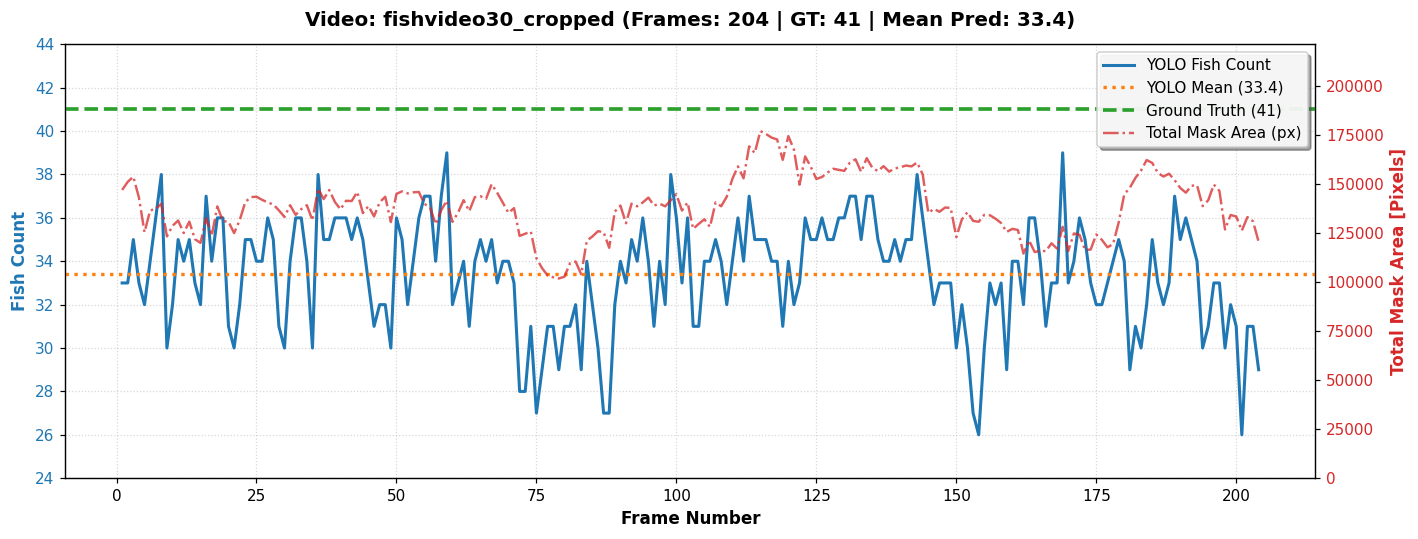

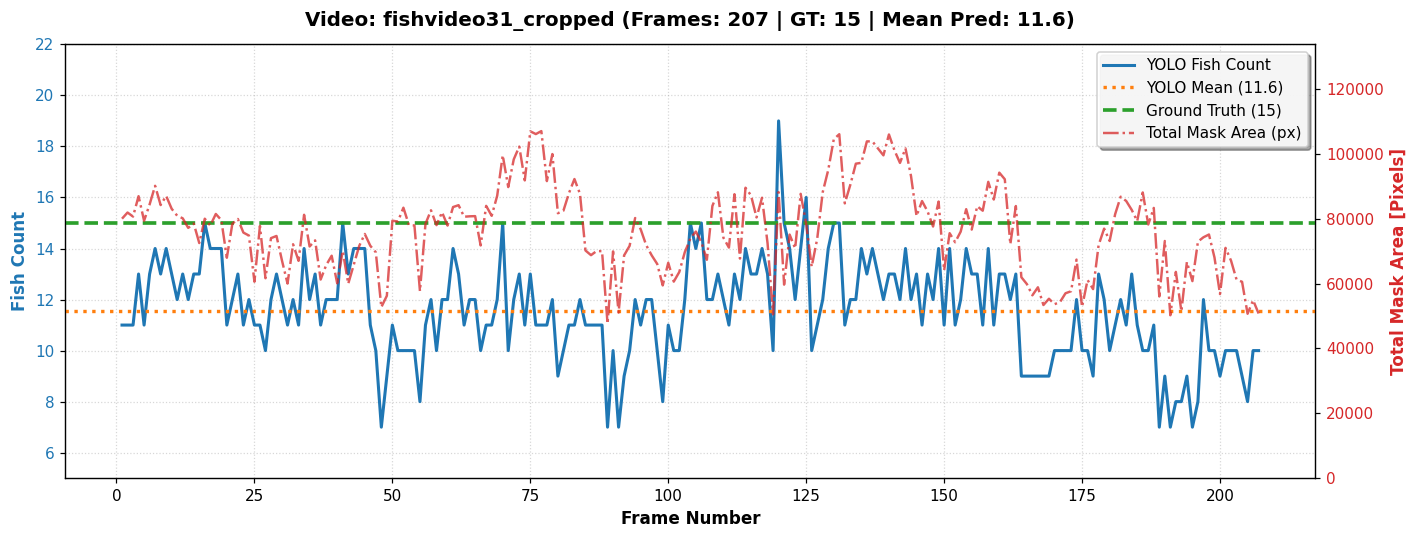

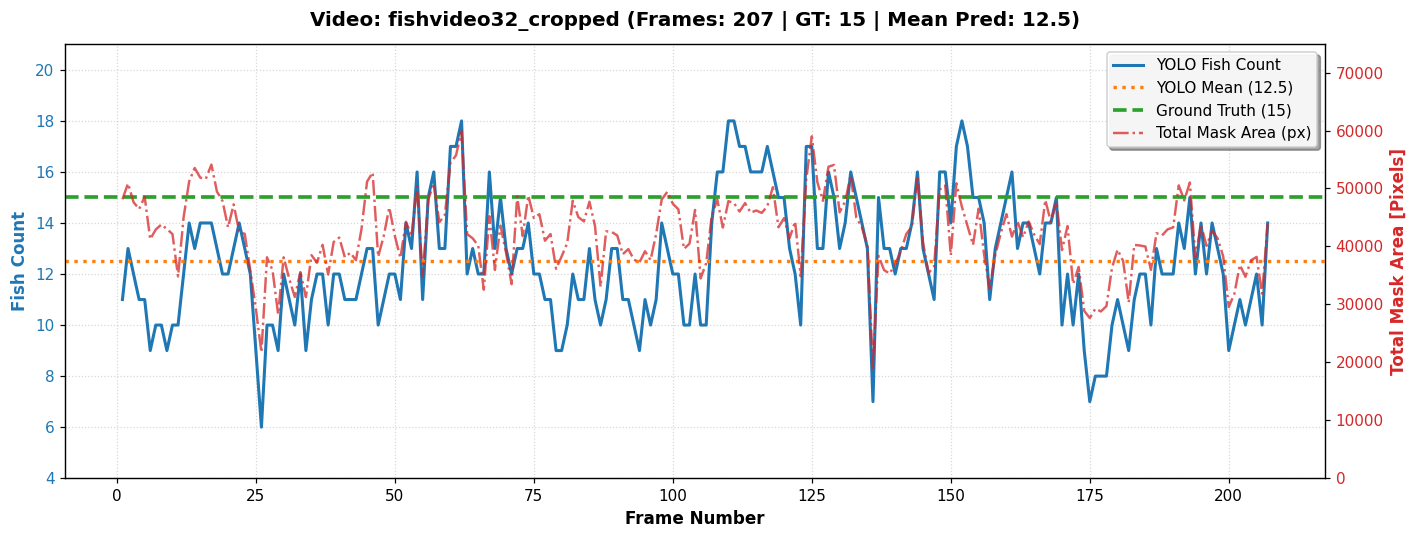

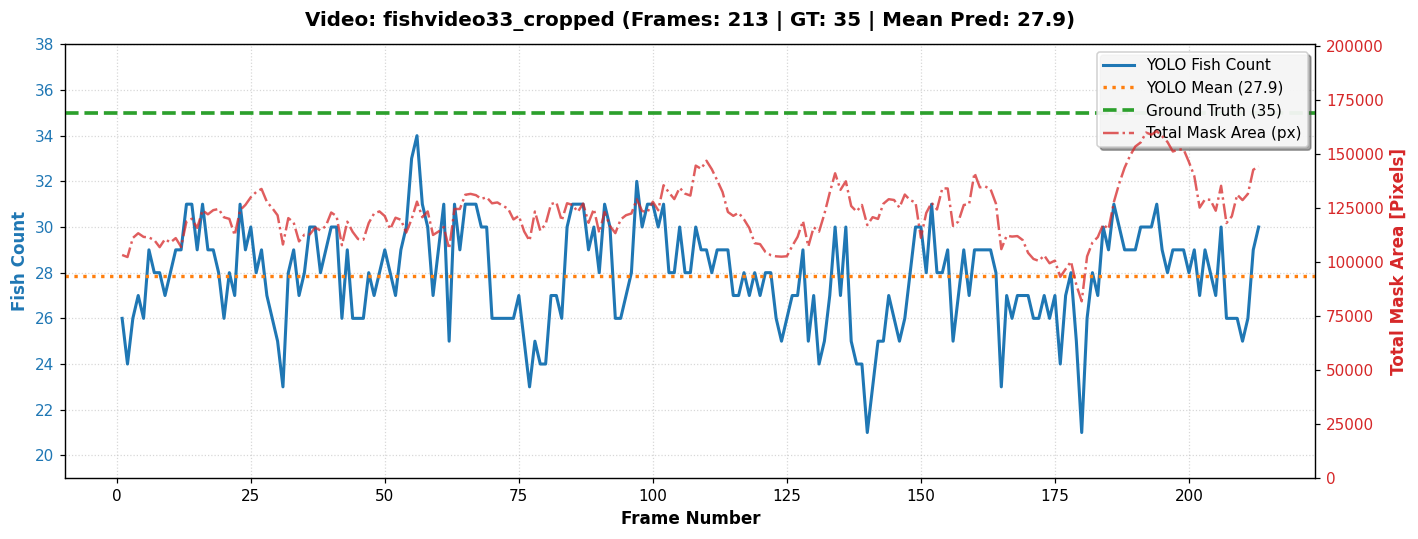

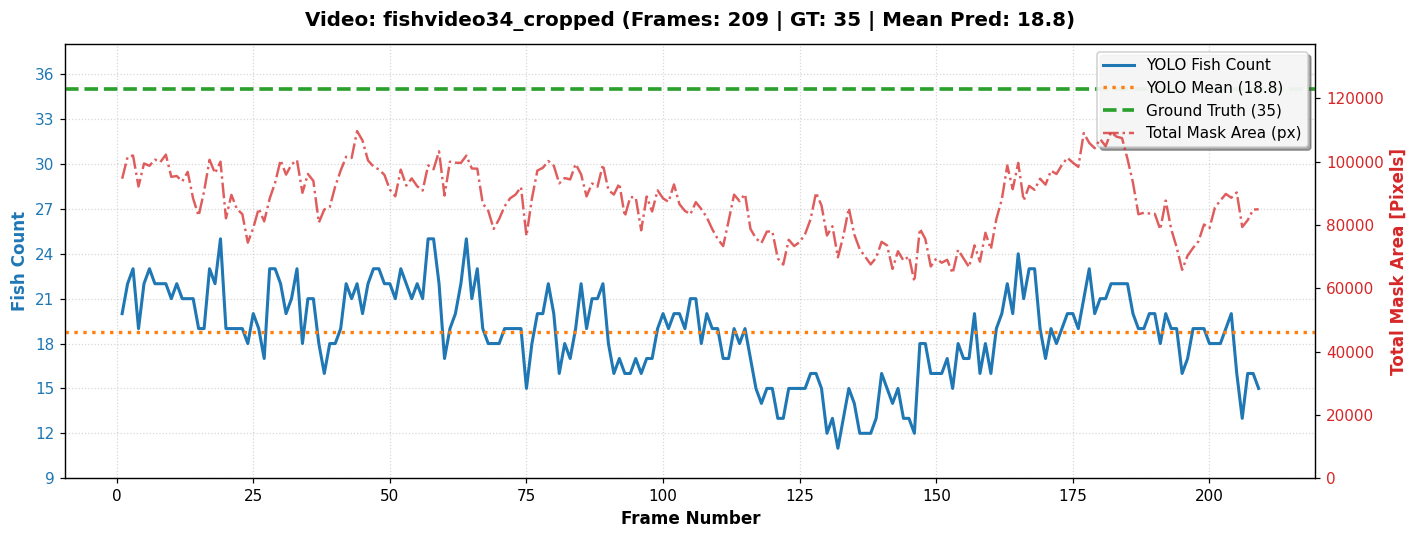

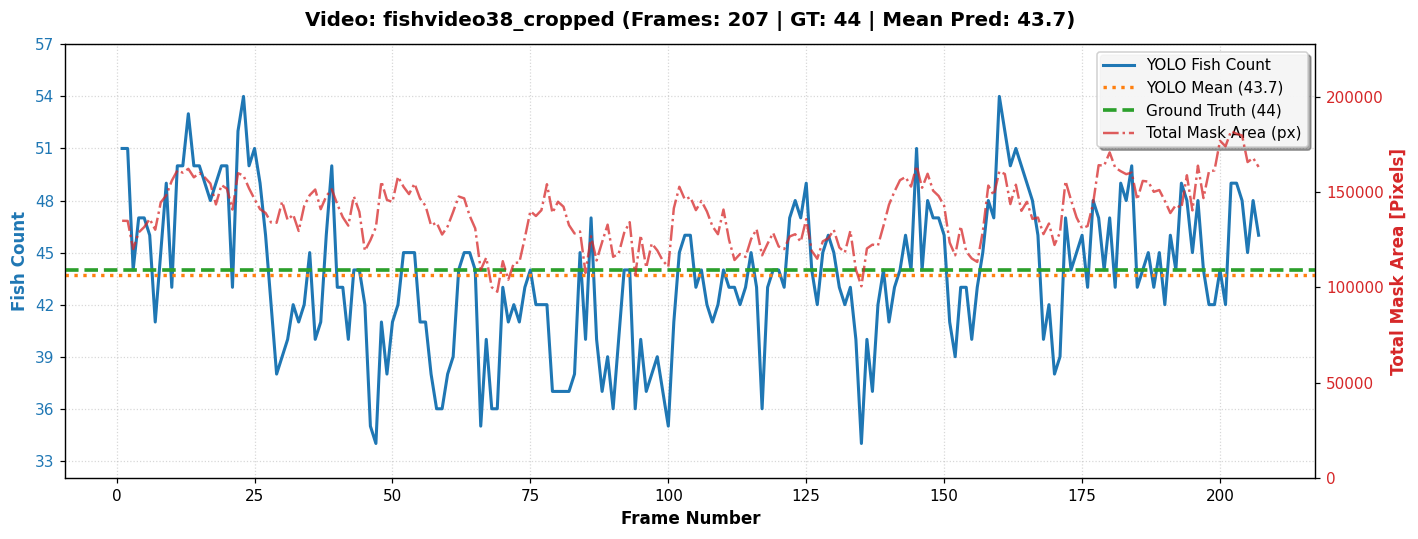

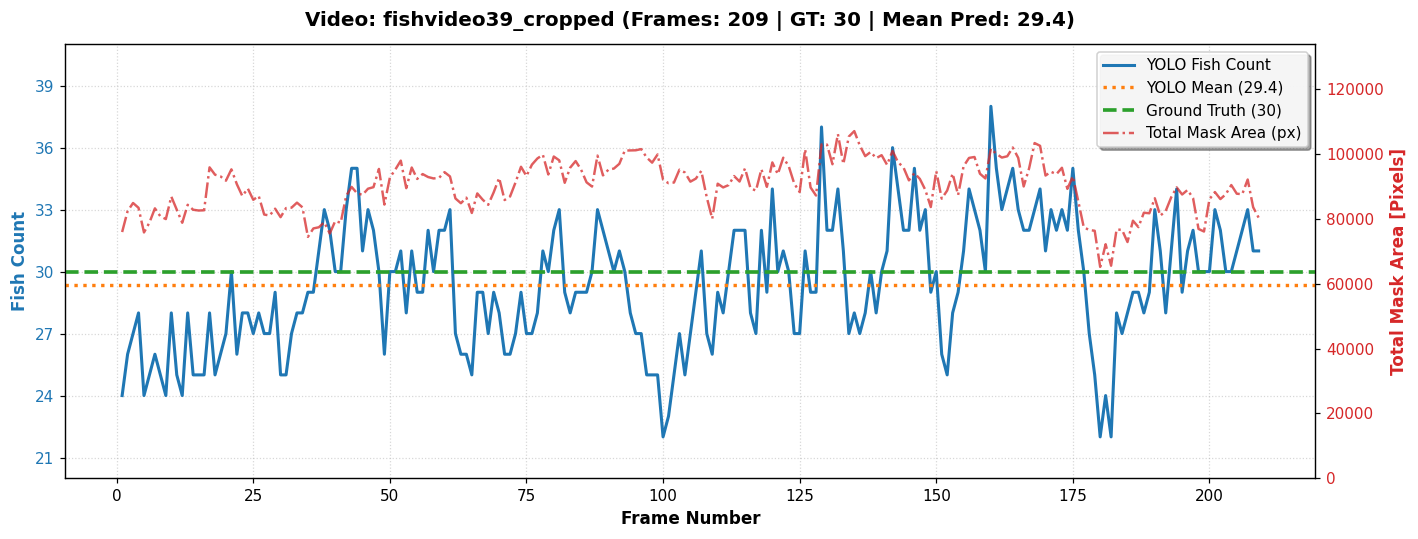

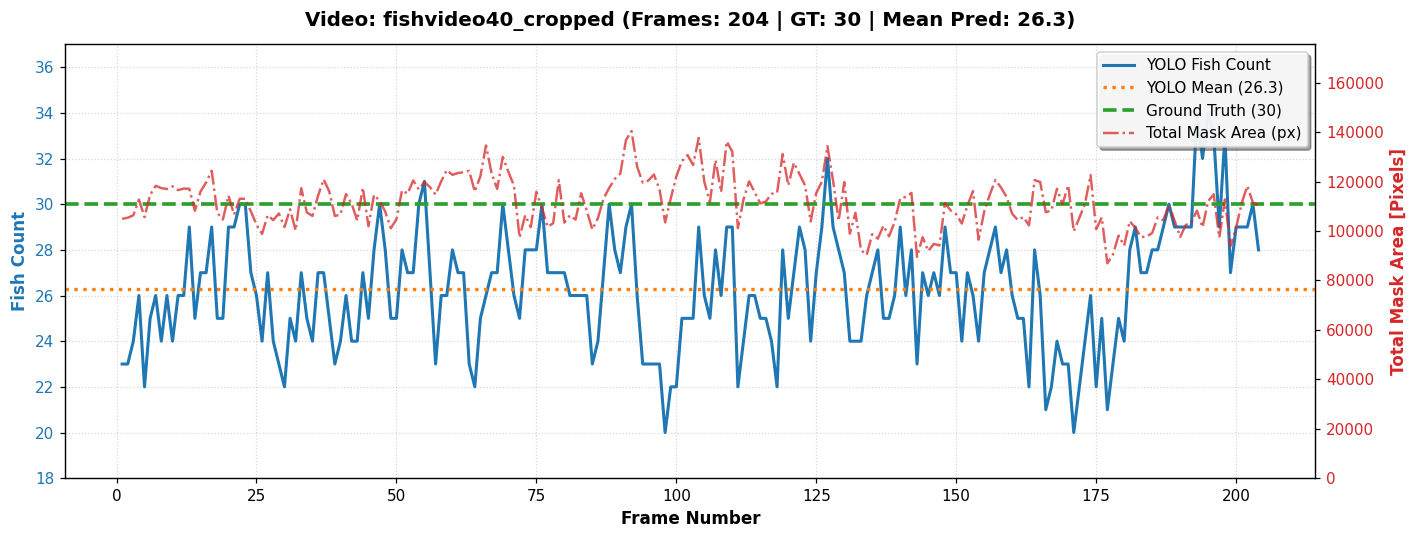

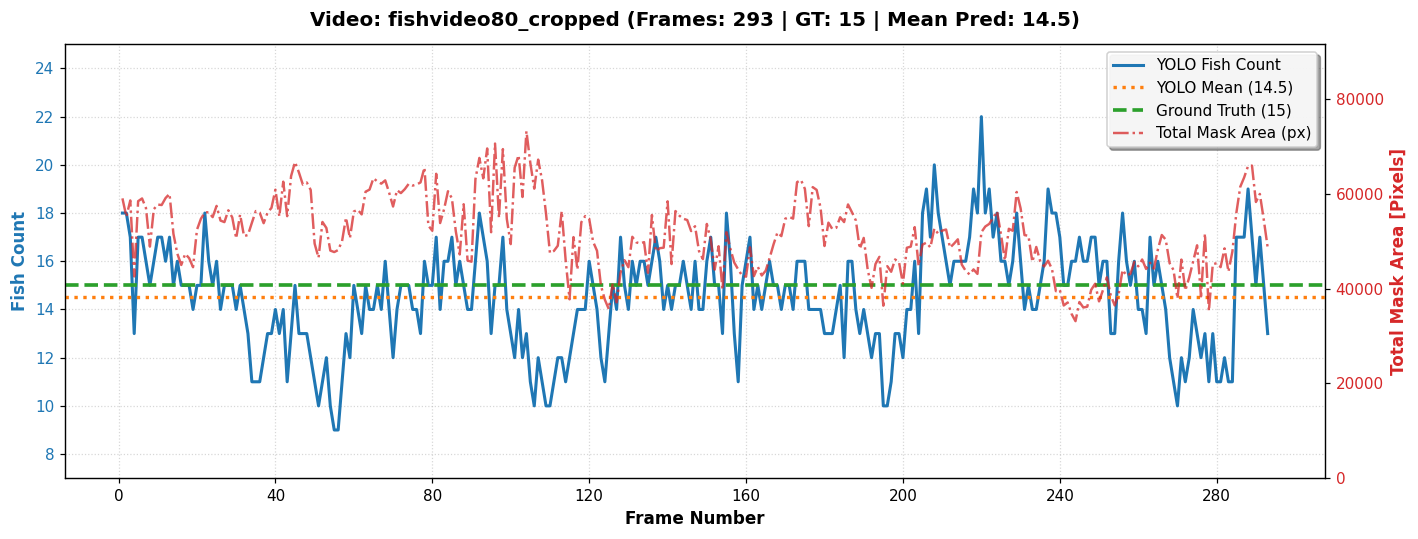

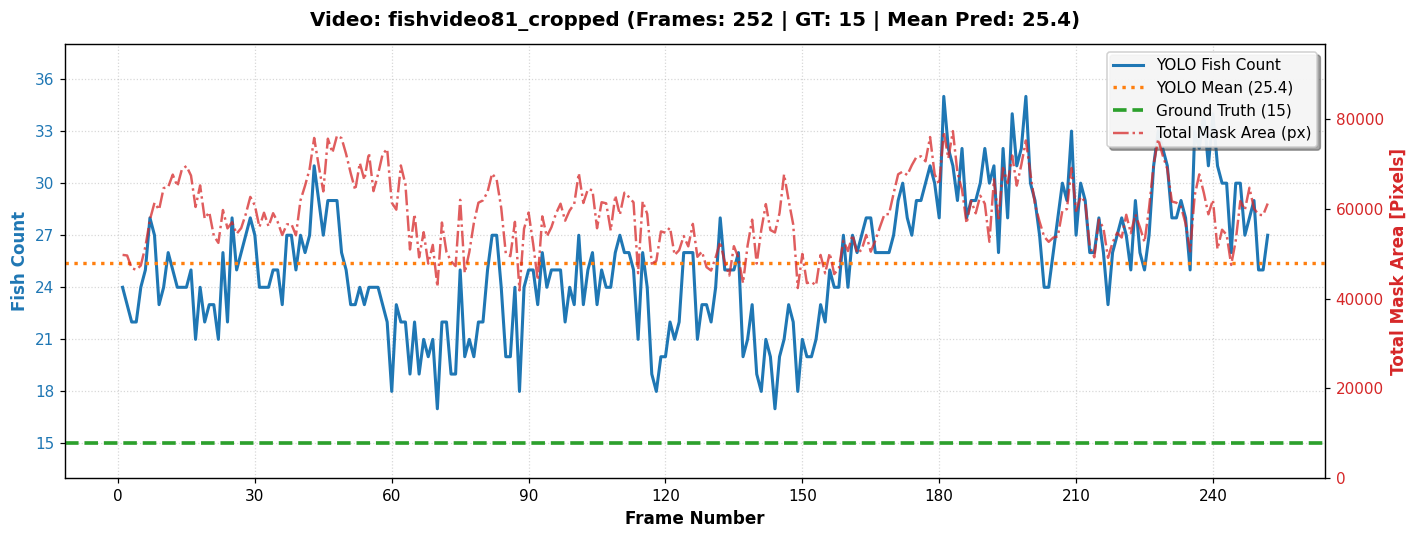

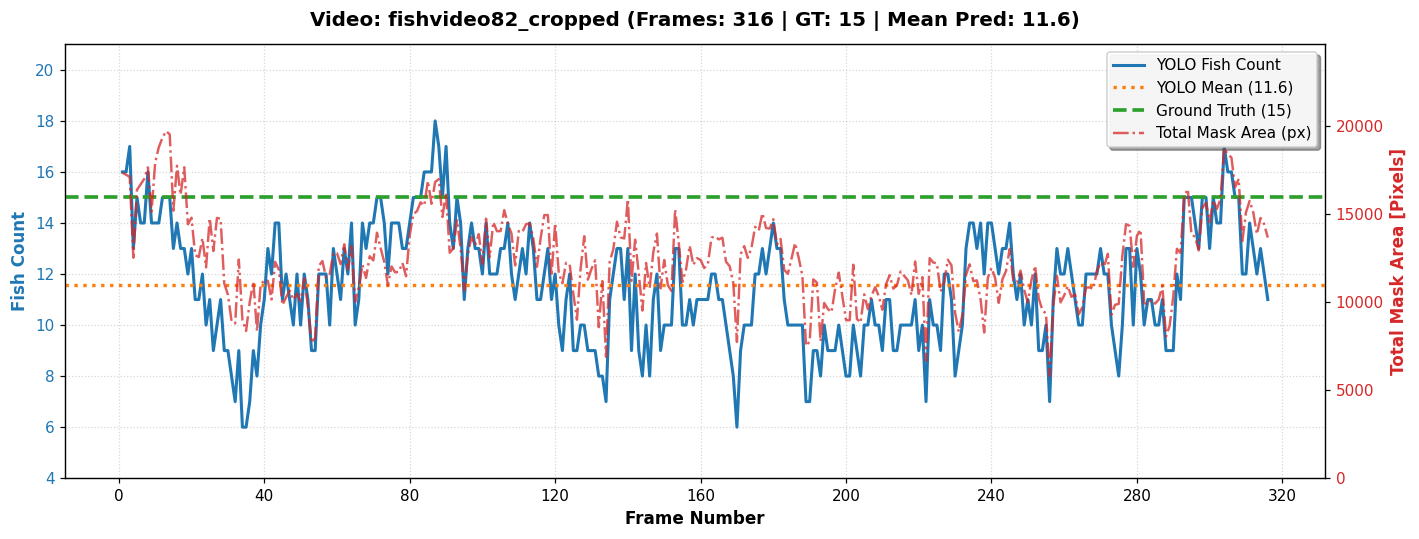

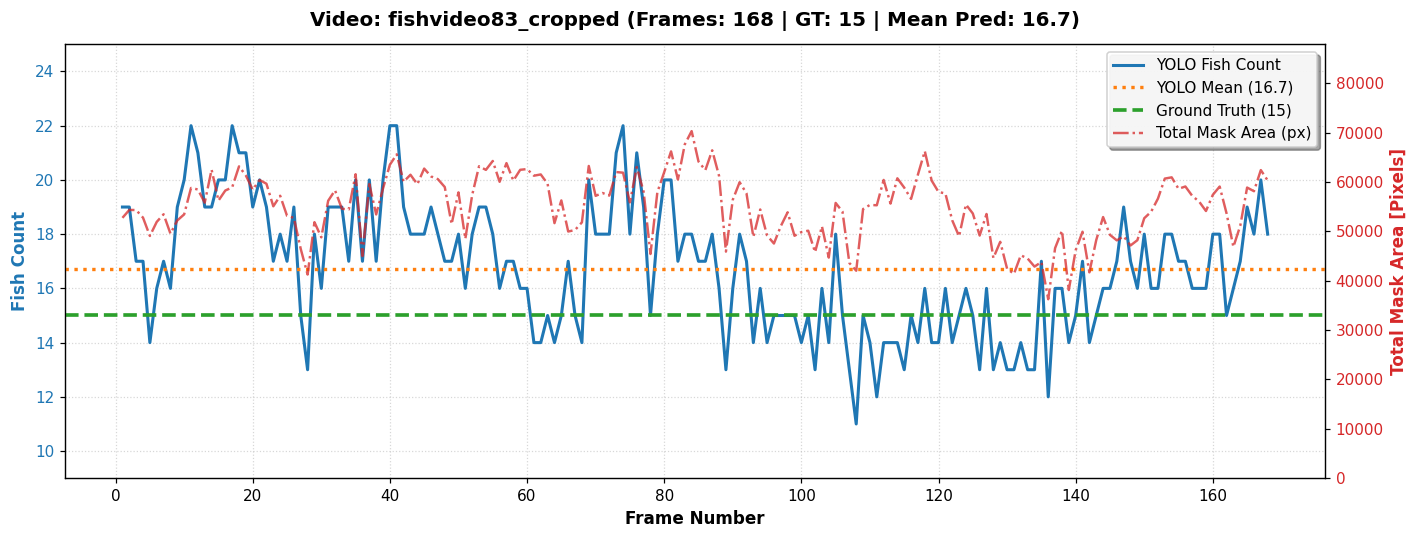

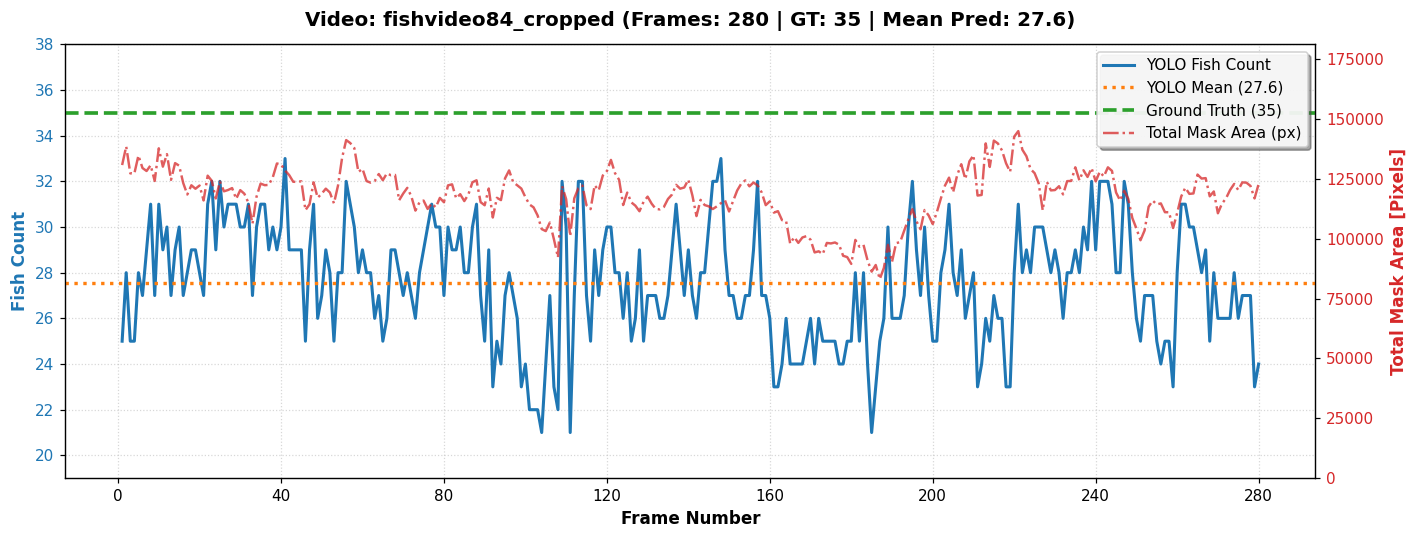

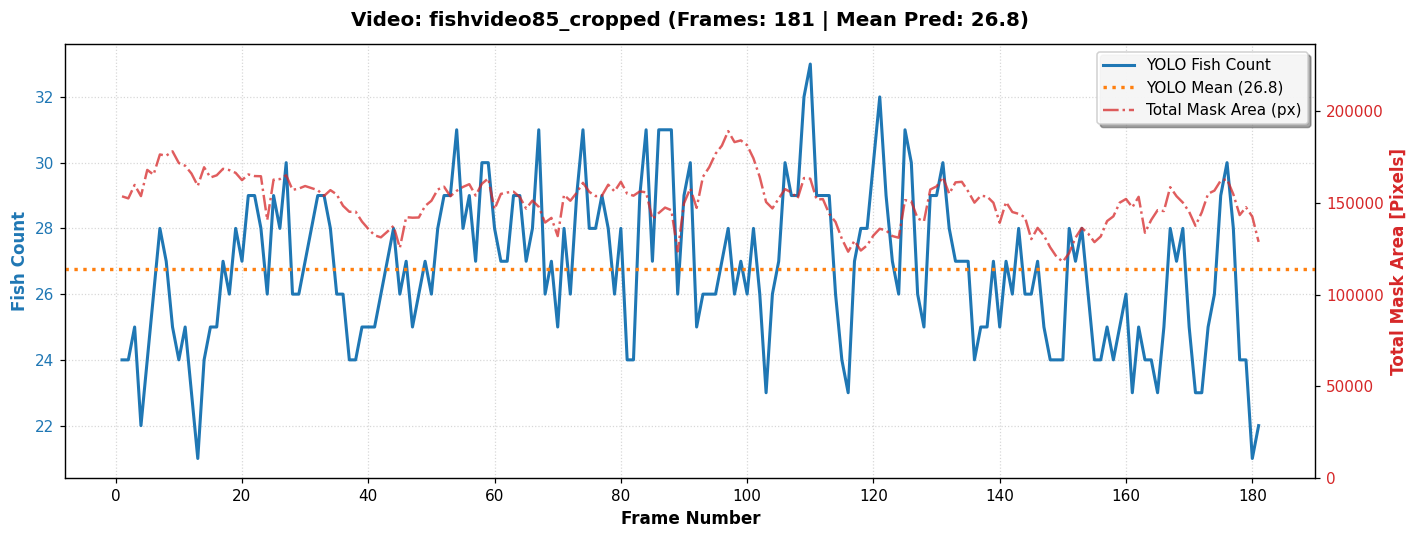

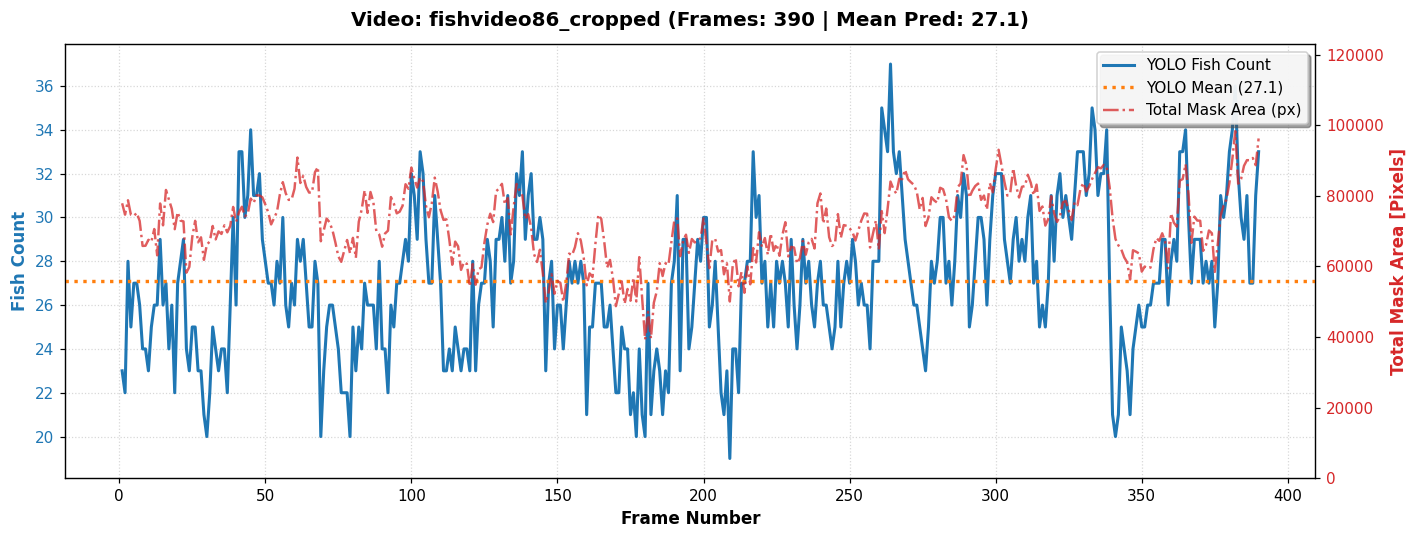

In [19]:
# ==============================================================================
# TIME-SERIES VISUALIZATION PER VIDEO (GT LINE & YOLO MEAN LINE)
# ==============================================================================

import matplotlib.ticker as ticker

# Ground truth fish counts per video
gt_counts = CONFIG.gt_counts

# Sort videos naturally by numeric ID
sorted_video_keys = sorted(
    results.keys(),
    key=lambda v: (
        int(re.findall(r"\d+", v)[0]) if re.findall(r"\d+", v) else v
    ),
)

for video_name in sorted_video_keys:
    frame_records = results[video_name]
    if not frame_records:
        continue

    # Extract time-series data
    frame_indices = list(range(1, len(frame_records) + 1))
    pred_counts = [r["fish_count"] for r in frame_records]
    mask_areas = [r["mask_area"] for r in frame_records]
    mean_pred = float(np.mean(pred_counts))

    # Robust matching for GT key (e.g. 'fishvideo30' from 'frames_fishvideo30_cropped')
    digits = re.findall(r"\d+", video_name)
    gt_key = f"fishvideo{digits[0]}" if digits else video_name
    gt_val = gt_counts.get(gt_key, None)

    # 1. Create dual-axis figure
    fig, ax1 = plt.subplots(figsize=(13, 5), dpi=110)
    ax2 = ax1.twinx()

    color_pred = "#1f77b4"  # Blue (Curve)
    color_mean = "#ff7f0e"  # Orange (YOLO Mean)
    color_gt = "#2ca02c"  # Green (Ground Truth)
    color_area = "#d62728"  # Red (Mask Area)

    # 2. Left Axis: YOLO Predictions Curve
    (line_pred,) = ax1.plot(
        frame_indices,
        pred_counts,
        color=color_pred,
        linewidth=2.0,
        label="YOLO Fish Count",
        zorder=3,
    )
    lines = [line_pred]
    labels = ["YOLO Fish Count"]

    # 3. Left Axis: YOLO Mean Line (Orange Dotted)
    line_mean = ax1.axhline(
        y=mean_pred,
        color=color_mean,
        linestyle=":",
        linewidth=2.2,
        label=f"YOLO Mean ({mean_pred:.1f})",
        zorder=4,
    )
    lines.append(line_mean)
    labels.append(f"YOLO Mean ({mean_pred:.1f})")

    # 4. Left Axis: Ground Truth Line (Green Dashed)
    if gt_val is not None:
        line_gt = ax1.axhline(
            y=gt_val,
            color=color_gt,
            linestyle="--",
            linewidth=2.4,
            label=f"Ground Truth ({gt_val})",
            zorder=5,
        )
        lines.append(line_gt)
        labels.append(f"Ground Truth ({gt_val})")

        # Set integer y-limits with padding around GT and predictions
        y_min = max(0, min(min(pred_counts), gt_val, mean_pred) - 2)
        y_max = max(max(pred_counts), gt_val, mean_pred) + 3
        ax1.set_ylim(y_min, y_max)

    # Force strictly integer ticks on the Fish Count Y-axis
    ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax1.set_xlabel("Frame Number", fontsize=11, fontweight="bold")
    ax1.set_ylabel(
        "Fish Count", color=color_pred, fontsize=11, fontweight="bold"
    )
    ax1.tick_params(axis="y", labelcolor=color_pred)
    ax1.grid(True, linestyle=":", alpha=0.5)

    # 5. Right Axis: Total Mask Area
    (line_area,) = ax2.plot(
        frame_indices,
        mask_areas,
        color=color_area,
        linewidth=1.6,
        linestyle="-.",
        alpha=0.75,
        label="Total Mask Area (px)",
        zorder=2,
    )
    lines.append(line_area)
    labels.append("Total Mask Area (px)")

    ax2.set_ylabel(
        "Total Mask Area [Pixels]",
        color=color_area,
        fontsize=11,
        fontweight="bold",
    )
    ax2.tick_params(axis="y", labelcolor=color_area)
    ax2.set_ylim(0, max(mask_areas) * 1.25 if max(mask_areas) > 0 else 1000)

    # 6. Title & Legend
    title_gt = f" | GT: {gt_val}" if gt_val is not None else ""
    plt.title(
        f"Video: {video_name} (Frames: {len(frame_indices)}{title_gt} | Mean Pred: {mean_pred:.1f})",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )

    ax1.legend(lines, labels, loc="upper right", framealpha=0.9, shadow=True)

    plt.tight_layout()
    plt.show()

## YOLO prediction on full video (with tracker)

In [30]:
# ==============================================================================
# TRACKING INFERENCE WITH OCCLUSION BUFFER (ACTIVE + BUFFERED / OCCLUDED FISH)
# ==============================================================================

# Buffer window: How many frames an unseen fish is kept as "temporarily occluded"
BUFFER_FRAMES = 30  # ~1 second at 30 fps

pattern = re.compile(r"^frames_fishvideo(\d+)_cropped$")
video_folders = sorted(
    [
        d
        for d in CONFIG.recordings_dir.iterdir()
        if d.is_dir() and pattern.match(d.name)
    ],
    key=lambda p: int(pattern.match(p.name).group(1)),
)

results_tracking: Dict[str, List[Dict[str, int]]] = {}


def get_sorted_frame_paths(folder: Path) -> List[Path]:
    frame_files = [f for f in folder.glob("*.jpg") if f.stem.isdigit()]
    return sorted(frame_files, key=lambda f: int(f.stem))


for folder in tqdm(video_folders, desc="Tracking Videos with Buffer"):
    video_num = pattern.match(folder.name).group(1)
    video_name = f"fishvideo{video_num}"

    frame_paths = get_sorted_frame_paths(folder)
    if not frame_paths:
        continue

    # Reset model & tracker per video
    model = YOLO(str(CONFIG.model_path))

    # Dictionary: {track_id: last_seen_frame_idx}
    last_seen_dict: Dict[int, int] = {}
    video_frame_records: List[Dict[str, int]] = []

    for frame_idx, img_path in enumerate(
        tqdm(frame_paths, desc=f"Tracking: {video_name}", leave=False)
    ):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue

        # Run ByteTrack
        pred = model.track(
            source=img_bgr,
            conf=CONFIG.conf_threshold,
            retina_masks=CONFIG.retina_masks,
            persist=True,
            tracker=str(CONFIG.tracker_config),
            verbose=False,
            device=CONFIG.device,
        )[0]

        # 1. Update last seen timestamp for active IDs
        active_ids = set()
        if pred.boxes is not None and pred.boxes.id is not None:
            active_ids = set([int(i) for i in pred.boxes.id.cpu().numpy()])
            for tid in active_ids:
                last_seen_dict[tid] = frame_idx

        active_count = len(active_ids)

        # 2. Count buffered/occluded fish (unseen for 1 to BUFFER_FRAMES)
        buffered_count = sum(
            1
            for tid, last_frame in last_seen_dict.items()
            if tid not in active_ids and (1 <= (frame_idx - last_frame) <= BUFFER_FRAMES)
        )

        # 3. Total estimated present = Visible + Occluded
        total_present = active_count + buffered_count

        # 4. Mask area
        if pred.masks is not None and len(pred.masks) > 0:
            raw_masks = (pred.masks.data.cpu().numpy() > 0.5).astype(np.uint8)
            combined_mask = np.any(raw_masks > 0, axis=0)
            total_mask_area = int(np.sum(combined_mask))
        else:
            total_mask_area = 0

        video_frame_records.append(
            {
                "active_count": active_count,          # Visible in this frame
                "buffered_count": buffered_count,      # Occluded / hidden in buffer
                "total_present": total_present,        # Visible + Occluded
                "mask_area": total_mask_area,
            }
        )

    results_tracking[video_name] = video_frame_records

logger.info(f"Buffered tracking complete for {len(results_tracking)} videos.")

Tracking Videos with Buffer:   0%|          | 0/15 [00:00<?, ?it/s]

Tracking: fishvideo30:   0%|          | 0/204 [00:00<?, ?it/s]

Tracking: fishvideo31:   0%|          | 0/207 [00:00<?, ?it/s]

Tracking: fishvideo32:   0%|          | 0/207 [00:00<?, ?it/s]

Tracking: fishvideo33:   0%|          | 0/213 [00:00<?, ?it/s]

...

Tracking: fishvideo83:   0%|          | 0/168 [00:00<?, ?it/s]

Tracking: fishvideo84:   0%|          | 0/280 [00:00<?, ?it/s]

Tracking: fishvideo85:   0%|          | 0/181 [00:00<?, ?it/s]

Tracking: fishvideo86:   0%|          | 0/390 [00:00<?, ?it/s]

[16:13:57] [INFO] Buffered tracking complete for 15 videos.


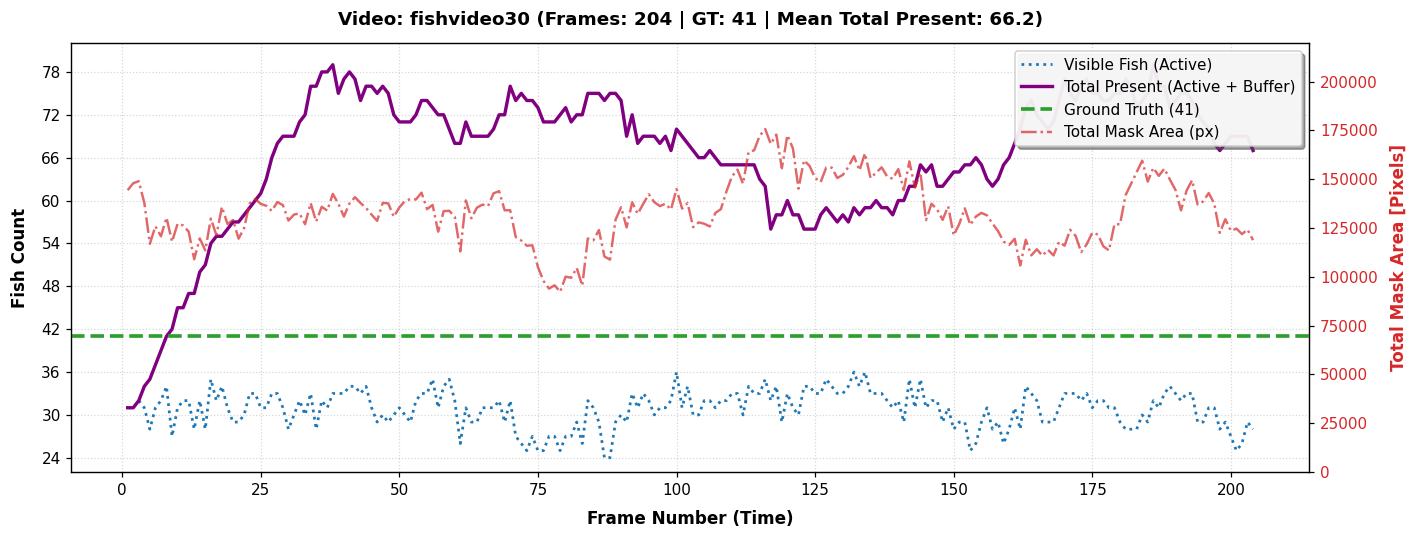

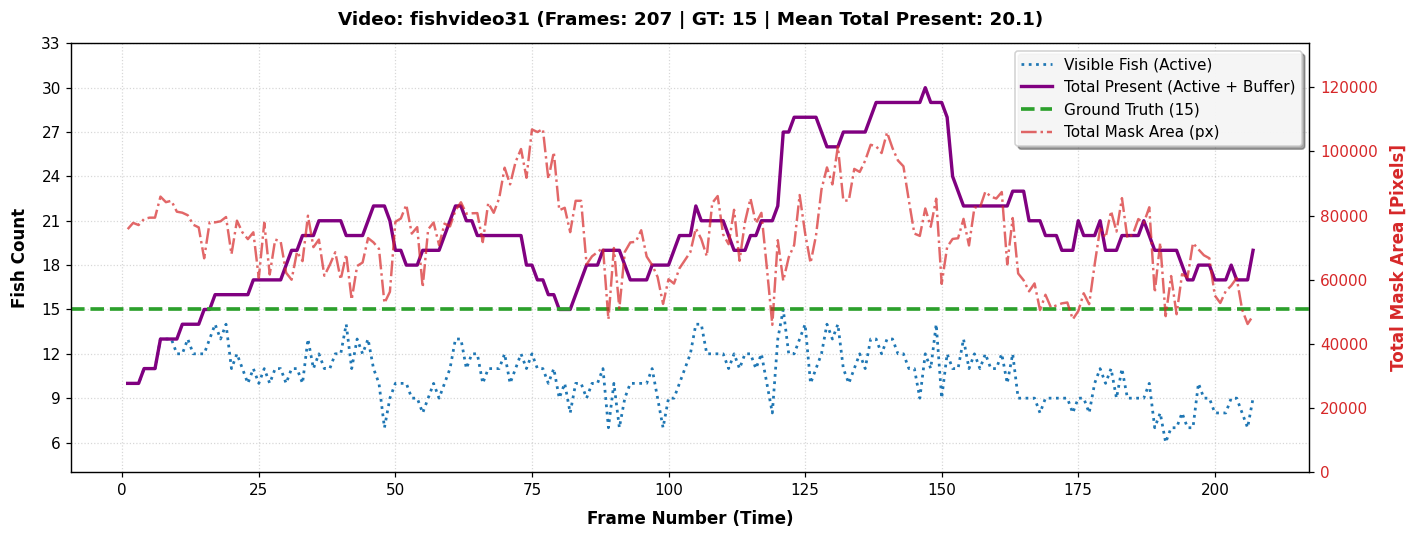

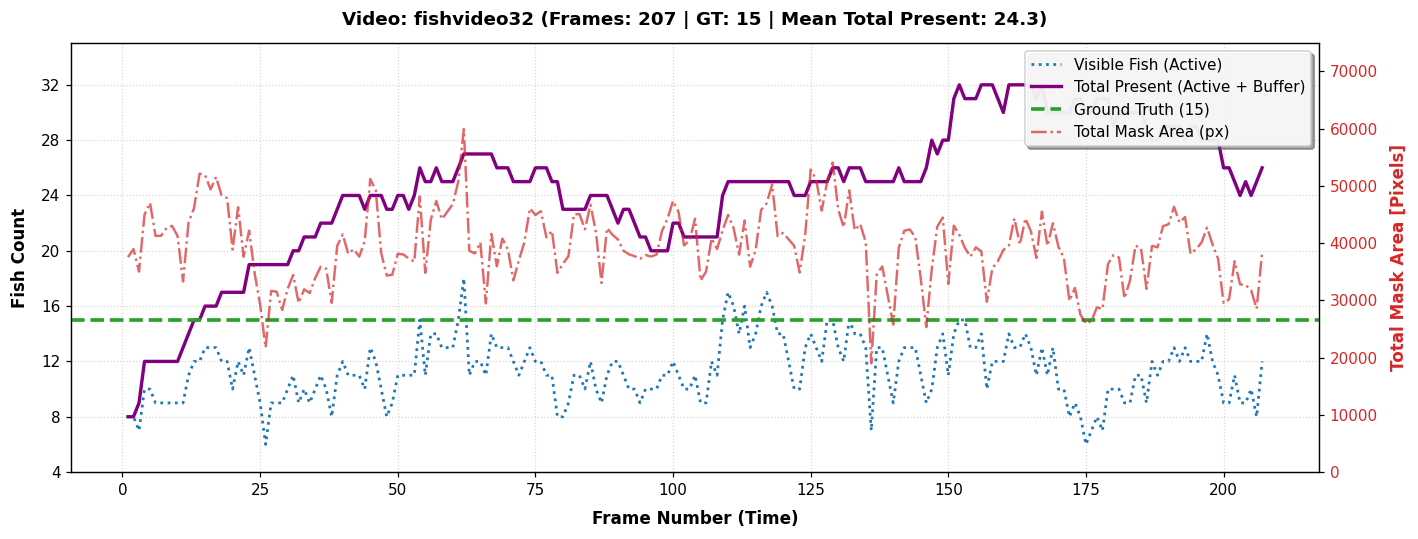

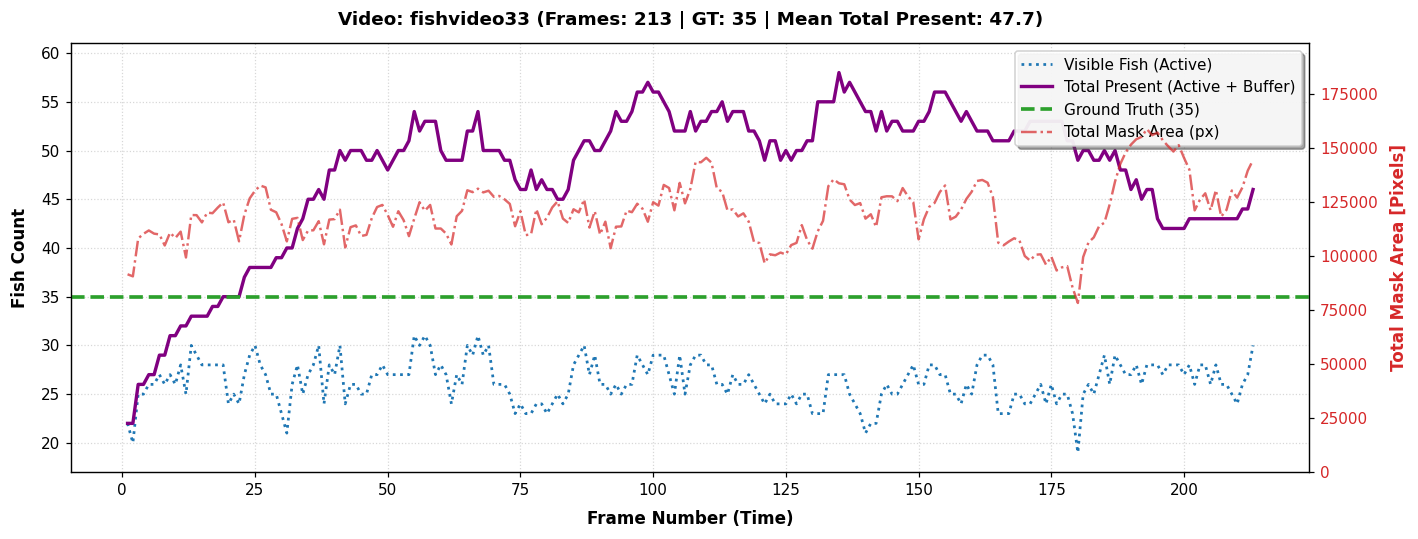

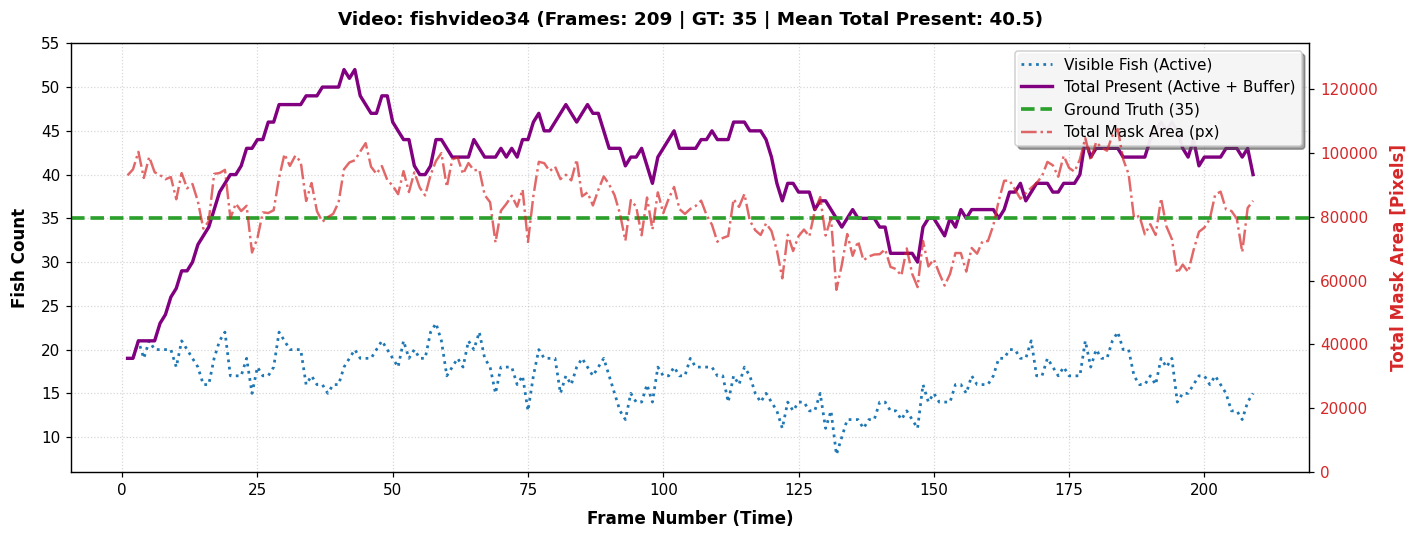

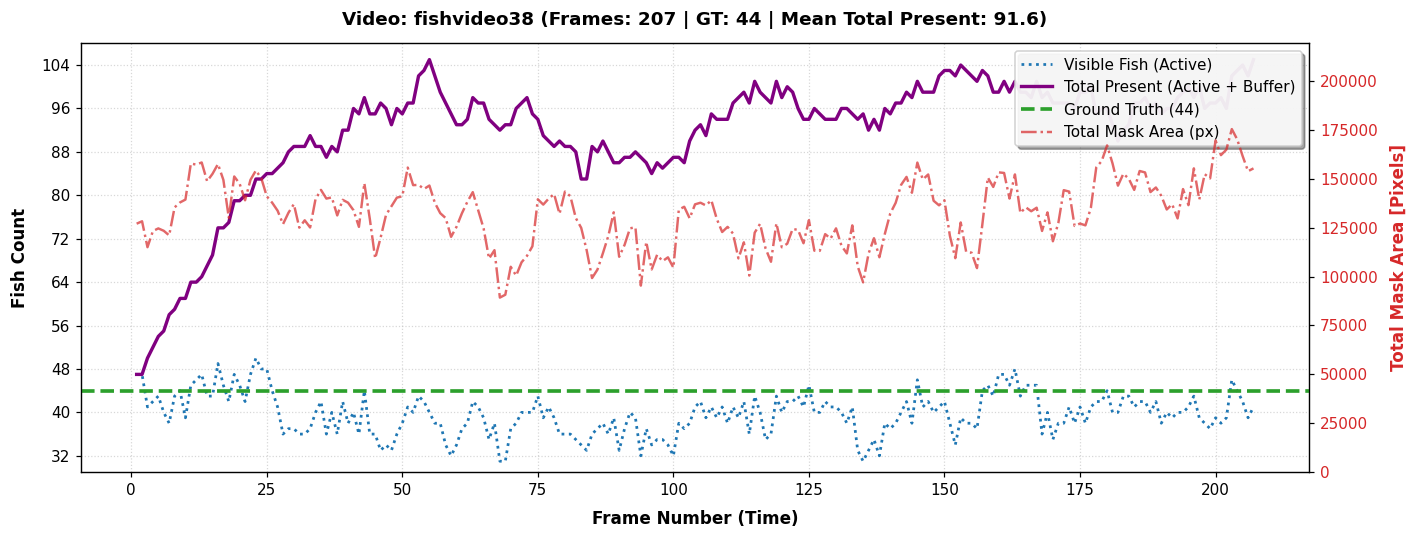

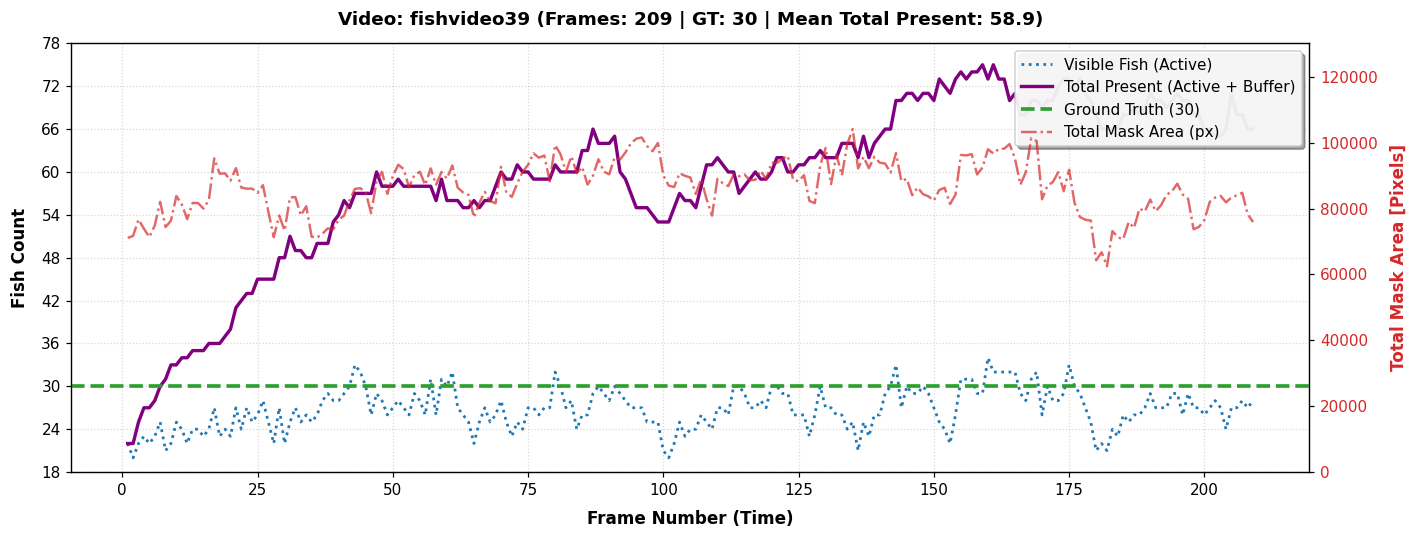

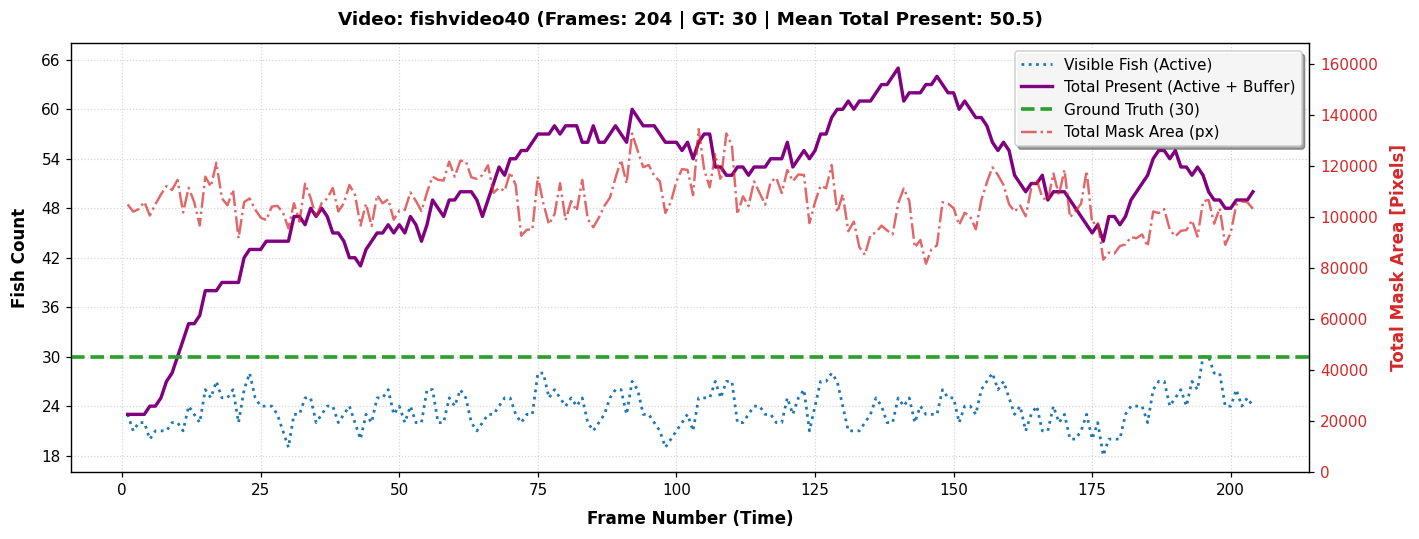

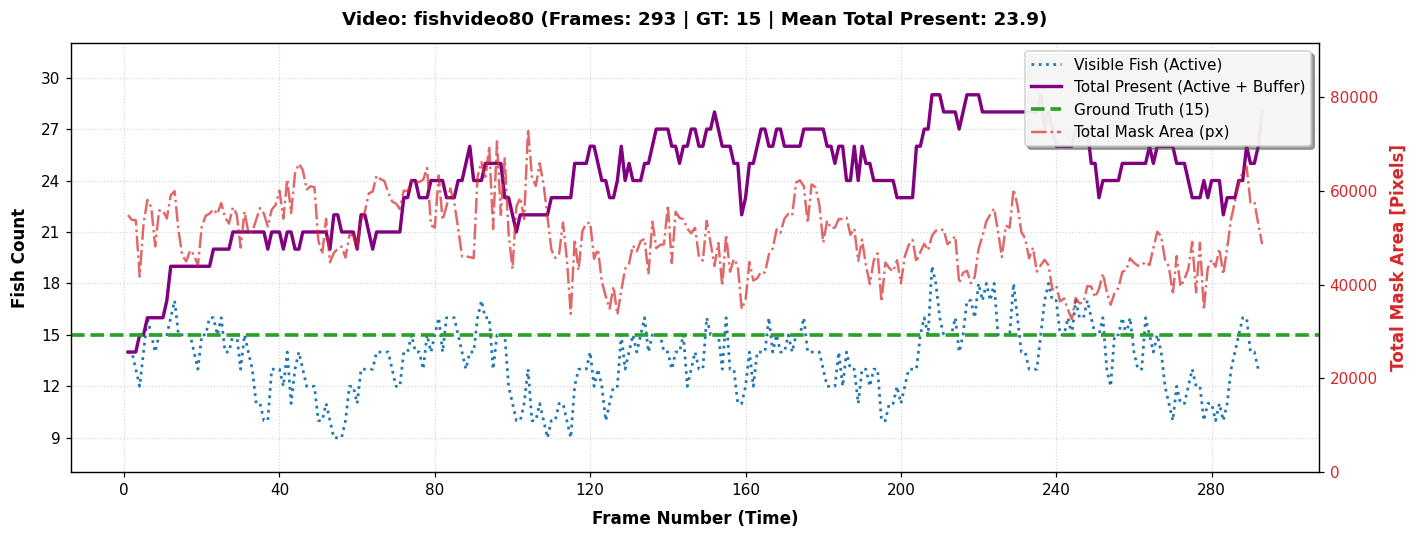

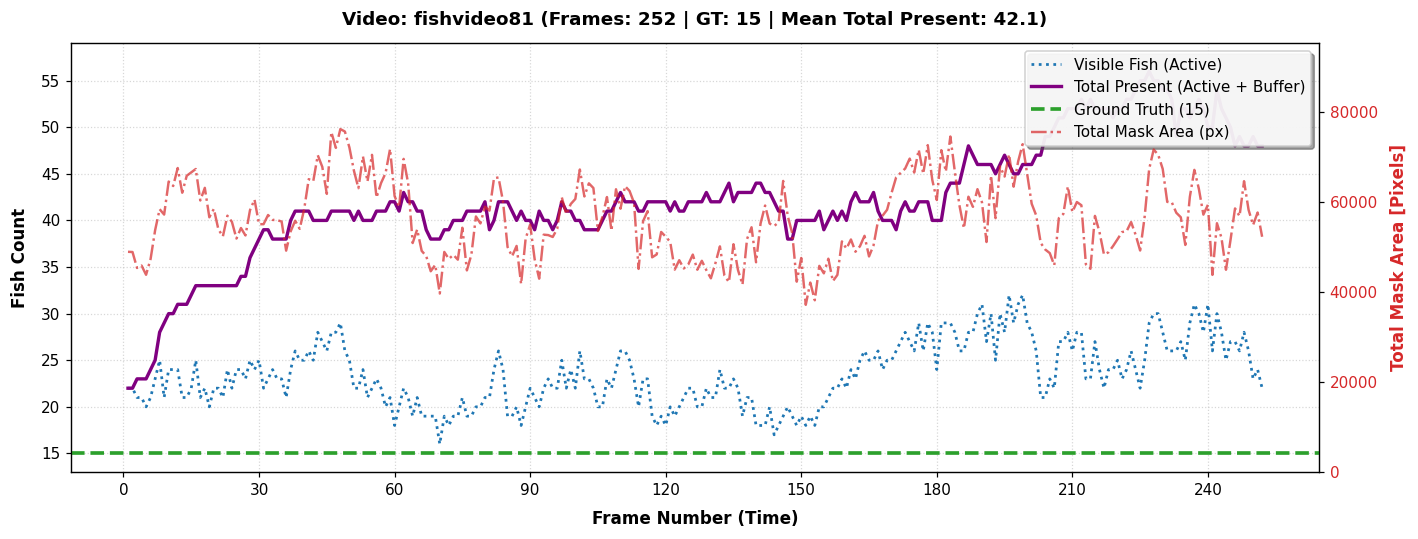

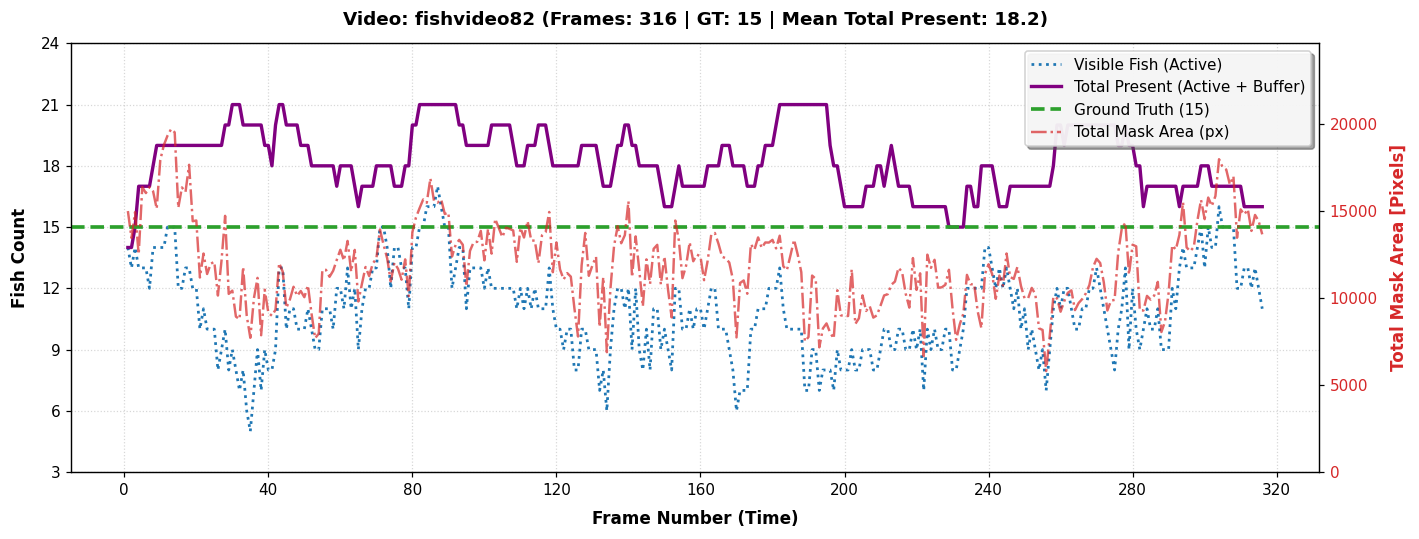

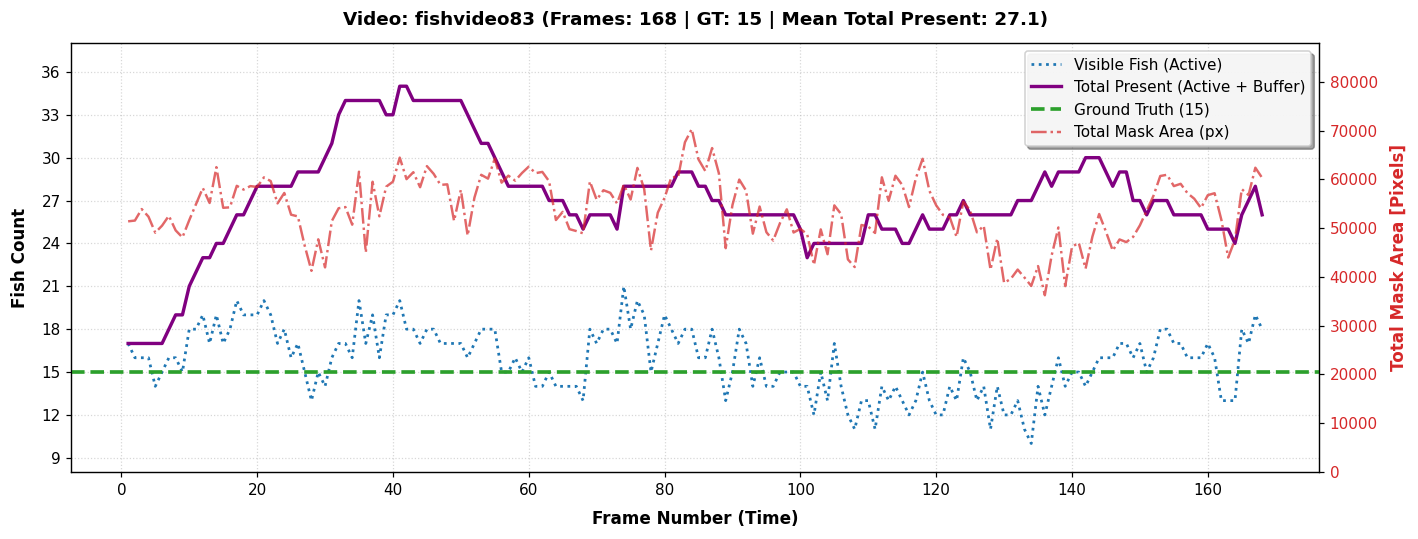

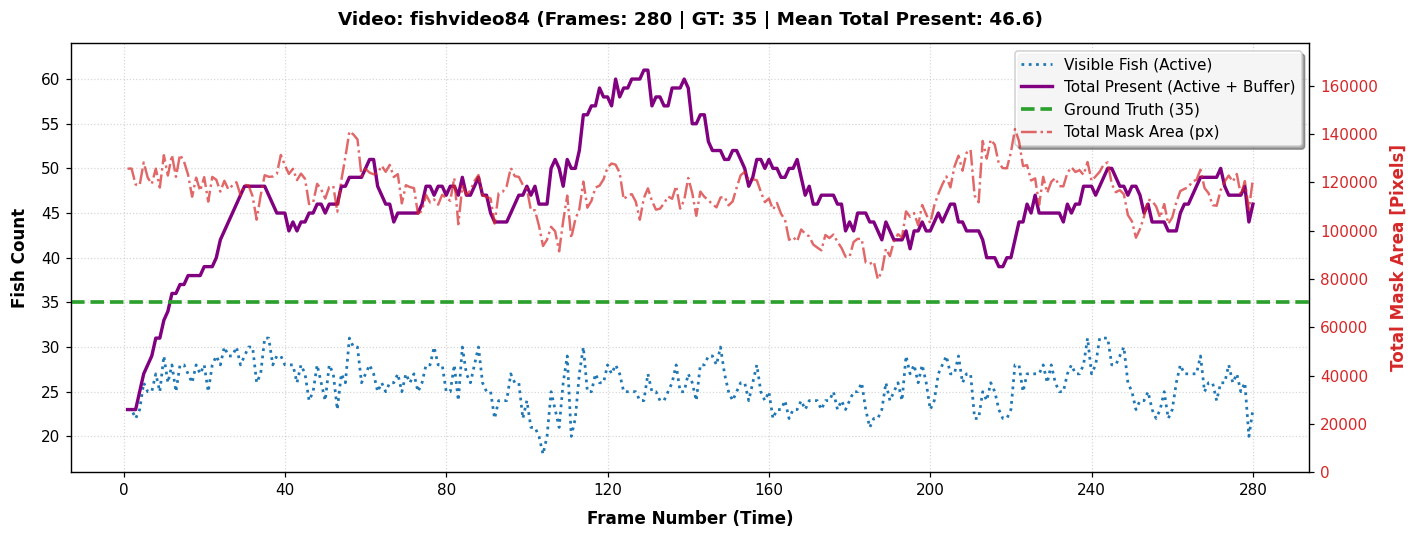

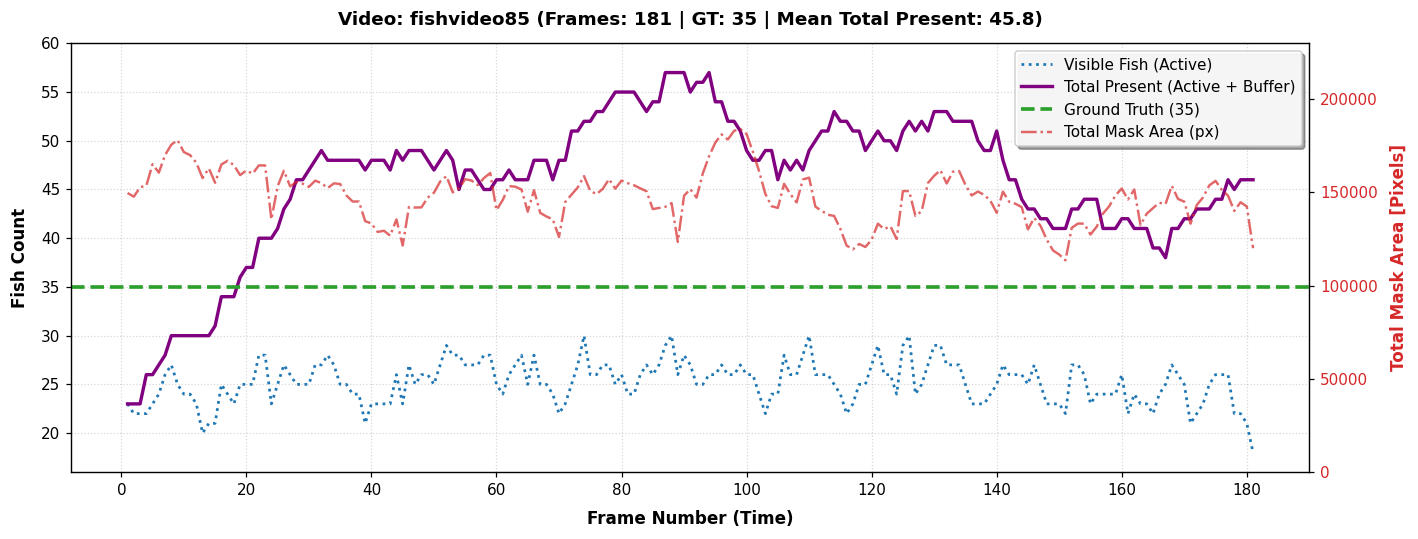

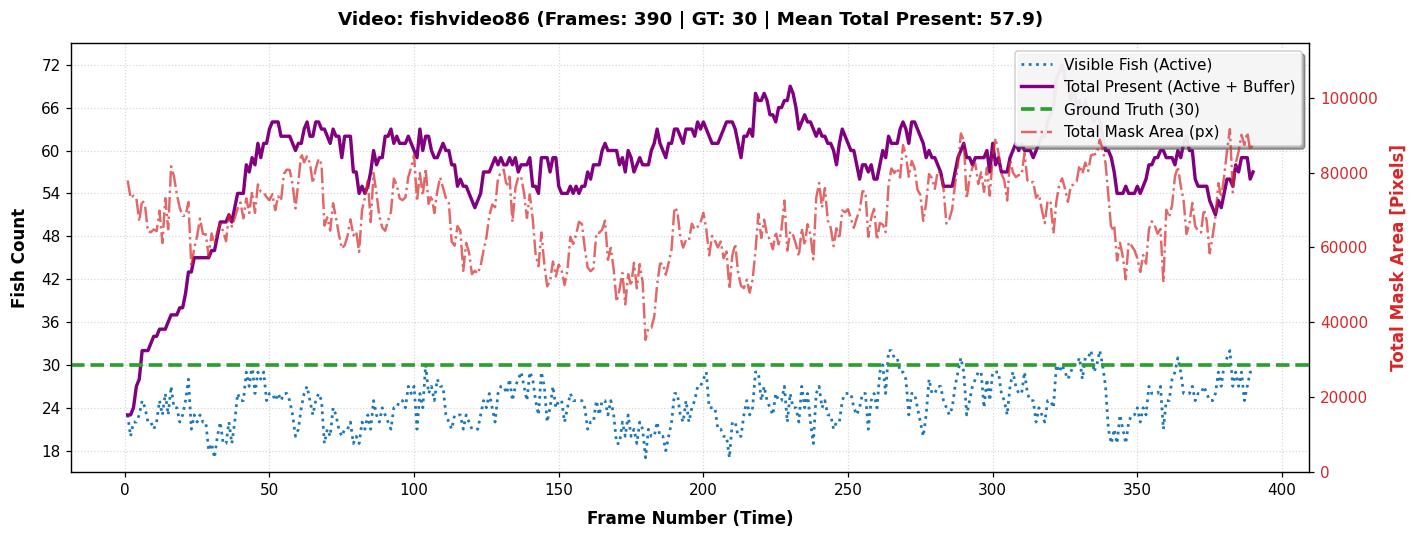

In [33]:
# ==============================================================================
# PLOT: ACTIVE VS. BUFFERED (OCCLUDED) FISH VS. GROUND TRUTH
# ==============================================================================

import matplotlib.ticker as ticker

sorted_video_keys = sorted(
    results_tracking.keys(),
    key=lambda v: (
        int(re.findall(r"\d+", v)[0]) if re.findall(r"\d+", v) else v
    ),
)

for video_name in sorted_video_keys:
    frame_records = results_tracking[video_name]
    if not frame_records:
        continue

    frame_indices = list(range(1, len(frame_records) + 1))
    active_counts = [r["active_count"] for r in frame_records]
    total_presents = [r["total_present"] for r in frame_records]
    mask_areas = [r["mask_area"] for r in frame_records]

    mean_total = float(np.mean(total_presents))

    # Match GT Count
    digits = re.findall(r"\d+", video_name)
    gt_key = f"fishvideo{digits[0]}" if digits else video_name
    gt_val = CONFIG.gt_counts.get(gt_key, None)

    # 1. Dual-Axis Setup
    fig, ax1 = plt.subplots(figsize=(13, 5), dpi=110)
    ax2 = ax1.twinx()

    color_active = "#1f77b4"   # Blue
    color_total = "#800080"    # Purple (Active + Buffered)
    color_gt = "#2ca02c"       # Green (Ground Truth)
    color_area = "#d62728"     # Red (Mask Area)

    # 2. Left Axis: Visible Active Fish
    line_active, = ax1.plot(
        frame_indices, active_counts,
        color=color_active, linewidth=1.8, linestyle=":",
        label="Visible Fish (Active)", zorder=3
    )

    # Left Axis: Total Present (Active + Occluded in Buffer)
    line_total, = ax1.plot(
        frame_indices, total_presents,
        color=color_total, linewidth=2.2,
        label=f"Total Present (Active + Buffer)", zorder=4
    )

    lines = [line_active, line_total]
    labels = ["Visible Fish (Active)", "Total Present (Active + Buffer)"]

    # Left Axis: Ground Truth Line
    if gt_val is not None:
        line_gt = ax1.axhline(
            y=gt_val, color=color_gt, linestyle="--", linewidth=2.4,
            label=f"Ground Truth ({gt_val})", zorder=5
        )
        lines.append(line_gt)
        labels.append(f"Ground Truth ({gt_val})")

        y_min = max(0, min(min(active_counts), gt_val) - 2)
        y_max = max(max(total_presents), gt_val) + 3
        ax1.set_ylim(y_min, y_max)

    # Integer ticks only
    ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax1.set_xlabel("Frame Number (Time)", fontsize=11, fontweight="bold", labelpad=8)
    ax1.set_ylabel("Fish Count", fontsize=11, fontweight="bold", labelpad=8)
    ax1.grid(True, linestyle=":", alpha=0.5)

    # 3. Right Axis: Total Mask Area
    line_area, = ax2.plot(
        frame_indices, mask_areas,
        color=color_area, linewidth=1.6, linestyle="-.", alpha=0.7,
        label="Total Mask Area (px)", zorder=2
    )
    lines.append(line_area)
    labels.append("Total Mask Area (px)")

    ax2.set_ylabel("Total Mask Area [Pixels]", color=color_area, fontsize=11, fontweight="bold", labelpad=8)
    ax2.tick_params(axis="y", labelcolor=color_area)
    ax2.set_ylim(0, max(mask_areas) * 1.25 if max(mask_areas) > 0 else 1000)

    # 4. Title & Legend
    title_gt = f" | GT: {gt_val}" if gt_val is not None else ""
    plt.title(
        f"Video: {video_name} (Frames: {len(frame_indices)}{title_gt} | Mean Total Present: {mean_total:.1f})",
        fontsize=12, fontweight="bold", pad=12
    )

    ax1.legend(lines, labels, loc="upper right", framealpha=0.9, shadow=True)

    plt.tight_layout()
    plt.show()

Further ideas:
- filter buffer tracks: delete tracks ids that are short lived, count only tracks that occur on n consecutively frames, ...
- maybe more complex filtering like track merging with re-identification?